# 0. Data Loading

In [3]:
import pandas as pd
import numpy as np
import shap
import joblib
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.preprocessing import *
from src.visualization import *
from src.metrics import *
from src.models import *

paw_pressures = pd.read_parquet("../data/paw_pressures.parquet")


/Users/leonardolorenzon/Desktop/Uni/Tesi/Progetto/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
paw_pressures.info()

<class 'pandas.DataFrame'>
MultiIndex: 9868500 entries, (np.float64(30.75), np.float64(-19.75), Timestamp('2019-01-01 00:00:00')) to (np.float64(59.75), np.float64(29.25), Timestamp('2024-12-31 00:00:00'))
Data columns (total 33 columns):
 #   Column      Dtype         
---  ------      -----         
 0   valid_time  datetime64[ns]
 1   msl         float32       
 2   msl_lag1d   float32       
 3   msl_lag2d   float32       
 4   msl_lag3d   float32       
 5   msl_lag4d   float32       
 6   msl_lag5d   float32       
 7   msl_lag6d   float32       
 8   msl_lag7d   float32       
 9   msl_lag8d   float32       
 10  msl_lag9d   float32       
 11  msl_lag10d  float32       
 12  msl_lag11d  float32       
 13  msl_lag12d  float32       
 14  msl_lag13d  float32       
 15  msl_lag14d  float32       
 16  msl_lag15d  float32       
 17  msl_lag16d  float32       
 18  msl_lag17d  float32       
 19  msl_lag18d  float32       
 20  msl_lag19d  float32       
 21  msl_lag20d  float32 

In [5]:
paw_pressures.tail(10)

valid_time          msl   msl_lag1d  \
latitude longitude time                                                      
59.75    20.25     2024-12-31 2024-12-31 22:00:00  100483.6875  100940.875   
         21.25     2024-12-31 2024-12-31 22:00:00  100566.4375  100926.375   
         22.25     2024-12-31 2024-12-31 22:00:00  100643.1875  100922.625   
         23.25     2024-12-31 2024-12-31 22:00:00  100705.4375  100922.375   
         24.25     2024-12-31 2024-12-31 22:00:00  100742.4375  100906.625   
         25.25     2024-12-31 2024-12-31 22:00:00  100753.6875  100871.625   
         26.25     2024-12-31 2024-12-31 22:00:00  100759.9375  100823.625   
         27.25     2024-12-31 2024-12-31 22:00:00  100770.6875  100766.875   
         28.25     2024-12-31 2024-12-31 22:00:00  100777.9375  100724.125   
         29.25     2024-12-31 2024-12-31 22:00:00  100752.9375  100645.375   

                               msl_lag2d   msl_lag3d  msl_lag4d  msl_lag5d  \
latitude longitude time                                                      
59.75    20.25     2024-12-31  101079.50  100965.125  100916.50  100736.25   
         21.25     2024-12-31  101047.25  100875.125  100834.25  100643.00   
         22.25     2024-12-31  100996.50  100785.875  100755.25  100560.50   
         23.25     2024-12-31  100948.75  100738.375  100679.25  100492.50   
         24.25     2024-12-31  100896.00  100689.375  100614.50  100437.00   
         25.25     2024-12-31  100832.75  100621.875  100536.25  100379.00   
         26.25     2024-12-31  100757.75  100548.625  100451.25  100316.50   
         27.25     2024-12-31  100666.50  100463.875  100378.75  100249.25   
         28.25     2024-12-31  100580.25  100393.125  100327.50  100200.50   
         29.25     2024-12-31  100497.50  100312.875  100254.00  100131.50   

                               msl_lag6d  msl_lag7d  msl_lag8d  ...  \
latitude longitude time                                         ...   
59.75    20.25     2024-12-31        NaN        NaN        NaN  ...   
         21.25     2024-12-31        NaN        NaN        NaN  ...   
         22.25     2024-12-31        NaN        NaN        NaN  ...   
         23.25     2024-12-31        NaN        NaN        NaN  ...   
         24.25     2024-12-31        NaN        NaN        NaN  ...   
         25.25     2024-12-31        NaN        NaN        NaN  ...   
         26.25     2024-12-31        NaN        NaN        NaN  ...   
         27.25     2024-12-31        NaN        NaN        NaN  ...   
         28.25     2024-12-31        NaN        NaN        NaN  ...   
         29.25     2024-12-31        NaN        NaN        NaN  ...   

                               msl_lag22d  msl_lag23d  msl_lag24d  msl_lag25d  \
latitude longitude time                                                         
59.75    20.25     2024-12-31         NaN         NaN         NaN         NaN   
         21.25     2024-12-31         NaN         NaN         NaN         NaN   
         22.25     2024-12-31         NaN         NaN         NaN         NaN   
         23.25     2024-12-31         NaN         NaN         NaN         NaN   
         24.25     2024-12-31         NaN         NaN         NaN         NaN   
         25.25     2024-12-31         NaN         NaN         NaN         NaN   
         26.25     2024-12-31         NaN         NaN         NaN         NaN   
         27.25     2024-12-31         NaN         NaN         NaN         NaN   
         28.25     2024-12-31         NaN         NaN         NaN         NaN   
         29.25     2024-12-31         NaN         NaN         NaN         NaN   

                               msl_lag26d  msl_lag27d  msl_lag28d  msl_lag29d  \
latitude longitude time                                                         
59.75    20.25     2024-12-31         NaN         NaN         NaN         NaN   
         21.25     2024-12-31         NaN         NaN         NaN         NaN   
         22.25 

# 1. Exploratory Data Analysis: Dataset Structure

## 1.1 Dataset dimensions, data types, and index


In [6]:
print_dataset_structure(paw_pressures, "paw_pressures")

  Dataset: paw_pressures
  Shape (rows, columns): (9868500, 33)
  N. rows: 9,868,500
  N. columns: 33

  --- Indexes per row ---
  [0] latitude     dtype=float64  range=[30.75, 59.75]  unique=30
  [1] longitude    dtype=float64  range=[-19.75, 29.25]  unique=50
  [2] time         dtype=datetime64[ns]  range=[2019-01-01 00:00:00, 2024-12-31 00:00:00]  unique=731

  --- Columns ---
  valid_time     dtype=datetime64[ns]
  msl            dtype=float32
  msl_lag1d      dtype=float32
  msl_lag2d      dtype=float32
  msl_lag3d      dtype=float32
  msl_lag4d      dtype=float32
  msl_lag5d      dtype=float32
  msl_lag6d      dtype=float32
  msl_lag7d      dtype=float32
  msl_lag8d      dtype=float32
  msl_lag9d      dtype=float32
  msl_lag10d     dtype=float32
  msl_lag11d     dtype=float32
  msl_lag12d     dtype=float32
  msl_lag13d     dtype=float32
  msl_lag14d     dtype=float32
  msl_lag15d     dtype=float32
  msl_lag16d     dtype=float32
  msl_lag17d     dtype=float32
  msl_lag18d     dtyp

## 1.2 Missing values

Missing values — paw_pressures
Column                Count        %
--------------------------------------
valid_time                0    0.00%
msl                 526,320    5.33%
msl_lag1d           529,160    5.36%
msl_lag2d           532,000    5.39%
msl_lag3d           534,840    5.42%
msl_lag4d           537,680    5.45%
msl_lag5d           540,520    5.48%
msl_lag6d         8,839,000   89.57%
msl_lag7d         8,840,420   89.58%
msl_lag8d         8,841,840   89.60%
msl_lag9d         8,843,260   89.61%
msl_lag10d        8,844,680   89.63%
msl_lag11d        8,846,100   89.64%
msl_lag12d        8,847,520   89.65%
msl_lag13d        8,848,940   89.67%
msl_lag14d        8,850,360   89.68%
msl_lag15d        8,851,780   89.70%
msl_lag16d        8,853,200   89.71%
msl_lag17d        8,854,620   89.73%
msl_lag18d        8,856,040   89.74%
msl_lag19d        8,857,460   89.75%
msl_lag20d        8,858,880   89.77%
msl_lag21d        8,860,300   89.78%
msl_lag22d        8,861,720   89.80%
msl_l

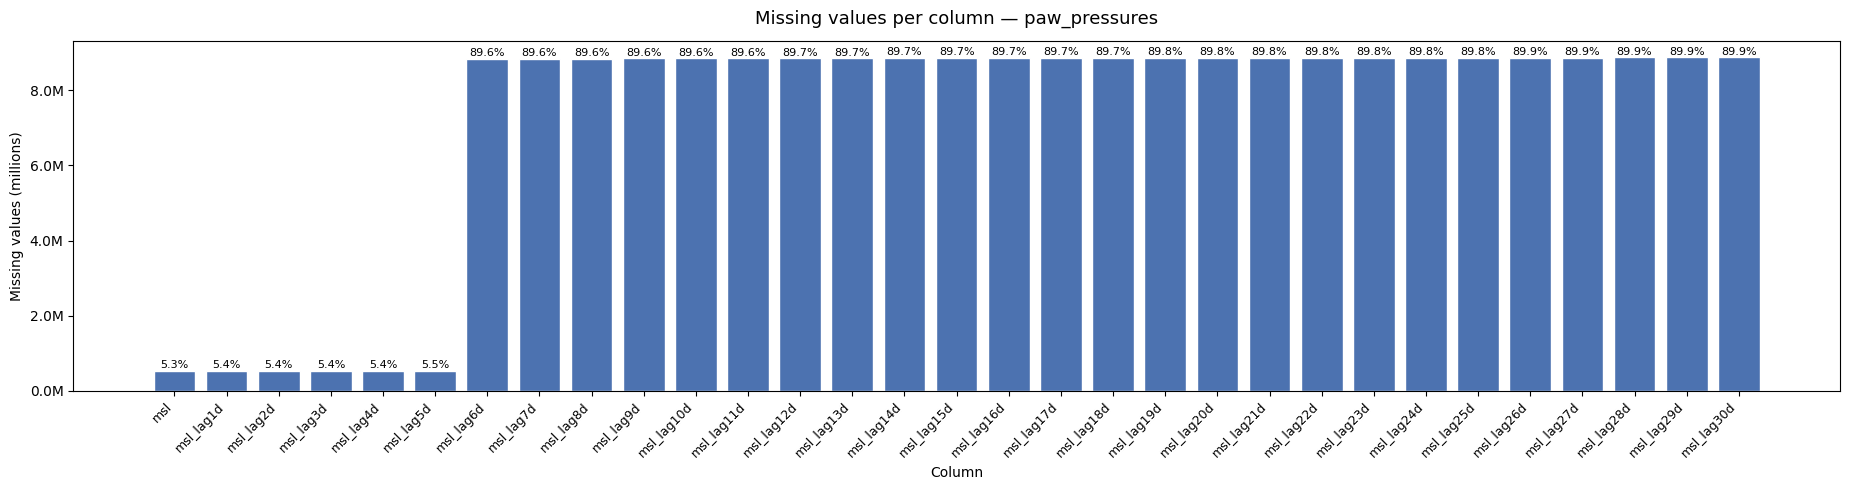

In [7]:
plot_missing(paw_pressures, "paw_pressures", "plots/paw/missing_paw.png")

## 1.3 Spatial grid uniformity


In [8]:
lats_paw, lons_paw = check_grid(paw_pressures, "paw_pressures")

Spatial grid — paw_pressures
  Unique latitudes:   30  range [30.75, 59.75]
  Unique longitudes:  50  range [-19.75, 29.25]
  Total grid points: 1500

  Spacing lat — min=1.0000  max=1.0000  std=0.000000  uniform=True
  Spacing lon — min=1.0000  max=1.0000  std=0.000000  uniform=True



## 1.4 Interactive spatial grid map


In [9]:
grid_lats, grid_lons = np.meshgrid(lats_paw, lons_paw)
grid_lats = grid_lats.ravel()
grid_lons = grid_lons.ravel()

plot_spatial_grid_map(
    grid_lats, grid_lons,
    venice_lat=45.44, venice_lon=12.33,
    venice_grid_lat=45.75, venice_grid_lon=12.25,
    title="Spatial grid — Europe and Mediterranean",
    save_path="plots/grid_map.png",
    n_grid_points=len(grid_lats),
)

# 2. Data Preprocessing and Train/Test Split

## 2.1 Feature matrix construction

In [10]:
pp_wide, y_paw = build_paw_features(
    paw_pressures,
    target_lat=45.75,
    target_lon=12.25,
)

=== paw_pressures — Preprocessing ===

[0] Original:             9,868,500 rows
    Timestamps: 731  —  Grid points: 1500
[1] Filter lag6d ≠ NaN:     1,029,500 rows
    Timestamps: 725  —  Grid points: 1420
[2] Drop residual NaN:      995,420 rows
    Timestamps: 701  —  Grid points: 1420
[3] Complete grid points:       995,420 rows  (1420 points — excluded 80: {(32.75, 6.25), (31.75, 8.25), (33.75, 5.25), (30.75, 6.25), (44.75, 8.25), (30.75, 27.25), (32.75, 8.25), (31.75, 10.25), (33.75, 7.25), (34.75, 8.25), (32.75, 1.25), (31.75, 3.25), (33.75, 0.25), (32.75, 10.25), (31.75, 12.25), (33.75, 9.25), (31.75, 21.25), (34.75, 1.25), (30.75, 22.25), (32.75, 3.25), (33.75, 2.25), (31.75, 14.25), (31.75, 23.25), (34.75, 3.25), (44.75, 5.25), (30.75, 15.25), (30.75, 24.25), (32.75, 5.25), (31.75, 7.25), (48.75, 23.25), (33.75, 4.25), (37.75, 29.25), (30.75, 8.25), (47.75, 24.25), (35.75, 4.25), (30.75, 17.25), (44.75, 16.25), (30.75, 26.25), (31.75, 0.25), (31.75, 9.25), (30.75, 1.25), (30.

## 2.2 Chronological split (80/20)

In [11]:
(   X_paw_train, X_paw_test,
    y_paw_train, y_paw_test,
    split_paw,
) = temporal_split(pp_wide, y_paw)

 TEMPORAL SPLIT — 80% train | 20% test (chronological order)

  Split point:  2024-08-13 00:00:00
  Train: X=(560, 44020)  y = 560
  period: 2019-01-31 00:00:00  -> 2024-08-12 00:00:00

  Test: X=(141, 44020)  y = 141
  period: 2024-08-13 00:00:00  -> 2024-12-31 00:00:00



# 3. Exploratory Data Analysis: Target Variable

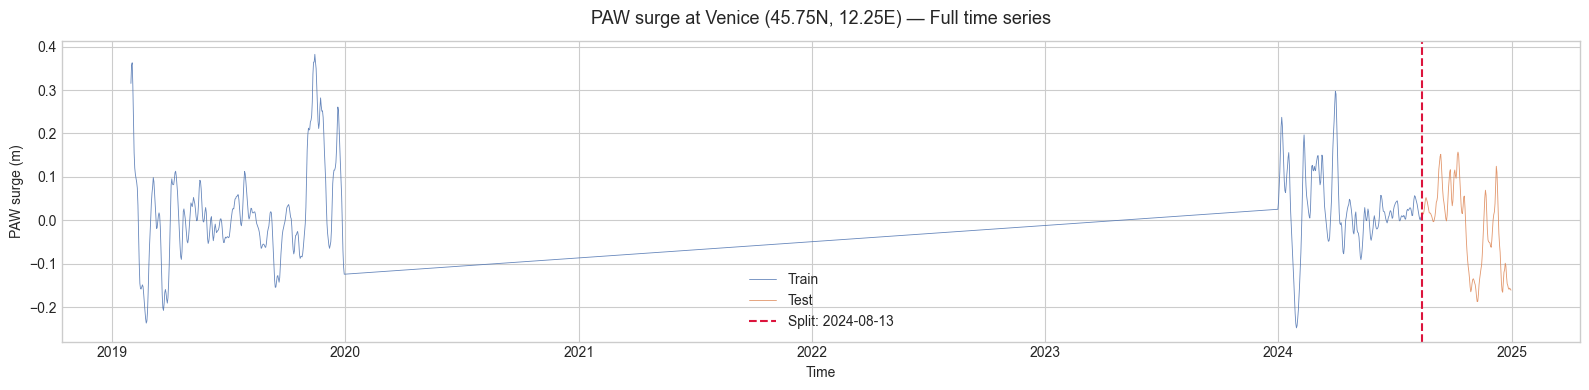

In [12]:
plot_target_timeseries(
    y_paw_train, y_paw_test, split_paw,
    title='PAW surge at Venice (45.75N, 12.25E) — Full time series',
    ylabel='PAW surge (m)',
    save_path='plots/paw/paw_timeseries.png',
    split_date_fmt='%Y-%m-%d',
)

## 3.1 Descriptive statistics

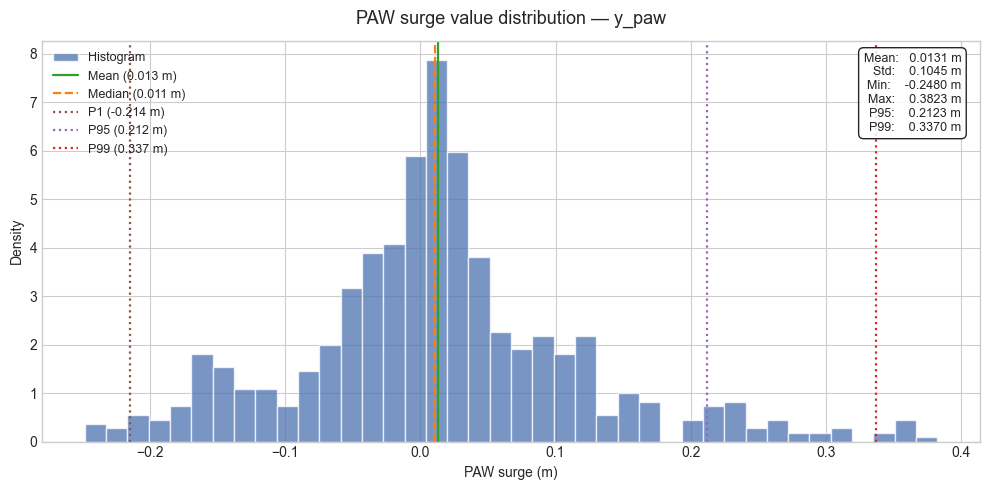

In [13]:

mean_p   = y_paw.mean()
median_p = y_paw.median()
std_p    = y_paw.std()
min_p    = y_paw.min()
max_p    = y_paw.max()
p01_p    = y_paw.quantile(0.01)
p95_p    = y_paw.quantile(0.95)
p99_p    = y_paw.quantile(0.99)

stat_lines = [
    (mean_p,   f'Mean ({mean_p:.3f} m)',     '#2ca02c', '-'),
    (median_p, f'Median ({median_p:.3f} m)', '#ff7f0e', '--'),
    (p01_p,    f'P1 ({p01_p:.3f} m)',        '#8c564b', ':'),
    (p95_p,    f'P95 ({p95_p:.3f} m)',       '#9467bd', ':'),
    (p99_p,    f'P99 ({p99_p:.3f} m)',       '#d62728', ':'),
]
plot_target_distribution(
    y_paw, stat_lines,
    title='PAW surge value distribution — y_paw',
    xlabel='PAW surge (m)',
    save_path='plots/paw/paw_distribution.png',
    bins=40,
)

## 3.2 Outlier analysis

In [14]:
outliers_paw_high = y_paw[y_paw > p99_p]
outliers_paw_low  = y_paw[y_paw < p01_p]

print('=== Outlier analysis y_paw — upper tail (values > P99) ===')
print(f'  P99 threshold:           {p99_p:.4f} m')
print(f'  N. outliers:             {len(outliers_paw_high):,}')
print(f'  Percentage of total:     {len(outliers_paw_high)/len(y_paw)*100:.2f}%')
print(f'  Minimum outlier value:   {outliers_paw_high.min():.4f} m')
print(f'  Maximum outlier value:   {outliers_paw_high.max():.4f} m')
print()
print('  Top 7 most extreme values (positive):')
print(f'  {"Date":<25} {"PAW surge (m)":>14}')
print('  ' + '-' * 40)
for ts, val in outliers_paw_high.nlargest(10).items():
    print(f'  {str(ts):<25} {val:>14.4f}')

print()
print('=== Outlier analysis y_paw — lower tail (values < P1) ===')
print(f'  P1 threshold:            {p01_p:.4f} m')
print(f'  N. outliers:             {len(outliers_paw_low):,}')
print(f'  Percentage of total:     {len(outliers_paw_low)/len(y_paw)*100:.2f}%')
print(f'  Minimum outlier value:   {outliers_paw_low.min():.4f} m')
print(f'  Maximum outlier value:   {outliers_paw_low.max():.4f} m')
print()
print('  Top 7 most extreme values (negative):')
print(f'  {"Date":<25} {"PAW surge (m)":>14}')
print('  ' + '-' * 40)
for ts, val in outliers_paw_low.nsmallest(10).items():
    print(f'  {str(ts):<25} {val:>14.4f}')

=== Outlier analysis y_paw — upper tail (values > P99) ===
  P99 threshold:           0.3370 m
  N. outliers:             7
  Percentage of total:     1.00%
  Minimum outlier value:   0.3495 m
  Maximum outlier value:   0.3823 m

  Top 7 most extreme values (positive):
  Date                       PAW surge (m)
  ----------------------------------------
  2019-11-15 00:00:00               0.3823
  2019-11-14 00:00:00               0.3646
  2019-11-13 00:00:00               0.3645
  2019-11-16 00:00:00               0.3640
  2019-02-02 00:00:00               0.3628
  2019-02-01 00:00:00               0.3572
  2019-11-17 00:00:00               0.3495

=== Outlier analysis y_paw — lower tail (values < P1) ===
  P1 threshold:            -0.2143 m
  N. outliers:             7
  Percentage of total:     1.00%
  Minimum outlier value:   -0.2480 m
  Maximum outlier value:   -0.2264 m

  Top 7 most extreme values (negative):
  Date                       PAW surge (m)
  -------------------------

# 4. Dimensionality Reduction (Principal Component Analysis)


## 4.1 Feature standardisation


In [15]:
X_train_scaled, X_test_scaled, scaler = fit_standard_scaler(
    X_paw_train,
    X_paw_test,
    save_path="models/paw/paw_scaler.pkl",
)

X_train_scaled shape: (560, 44020)
X_test_scaled  shape: (141, 44020)
Standardisation complete (fit on train only).


## 4.2 Exploratory PCA and variance explained


Maximum computable components: 560
  Components for 90% of variance: 67
  Components for 95% of variance: 115
  Components for 99% of variance: 268


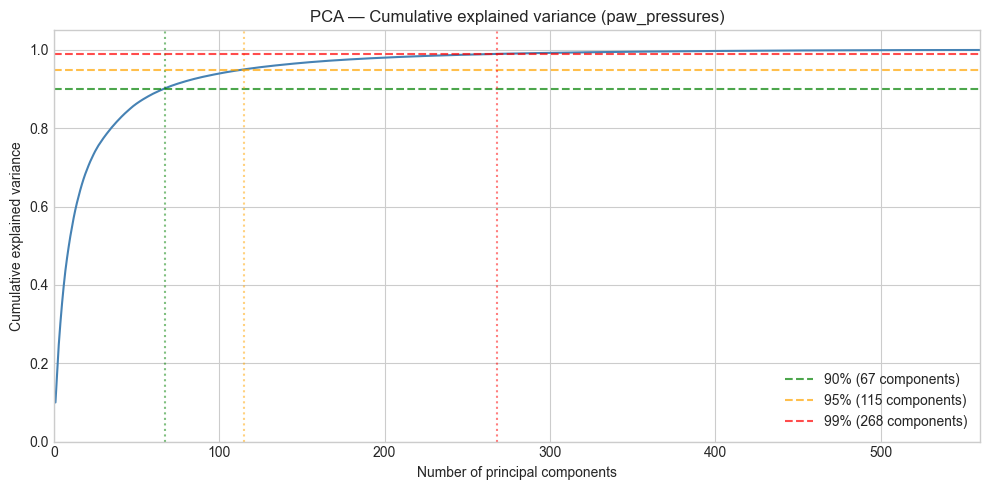

In [16]:
n_comp_per_threshold = explore_pca_variance(
    X_train_scaled,
    plot_path="plots/paw/pca_variance_explained.png",
)

## 4.3 Final PCA transform

In [17]:
X_paw_train_pca, X_paw_test_pca, pca = apply_pca(
    X_train_scaled,
    X_test_scaled,
    n_components=n_comp_per_threshold["95%"],
    save_path="models/paw/paw_pca.pkl",
)

Selected components: 115
X_train_pca shape: (560, 115)
X_test_pca  shape: (141, 115)


# 5. XGBoost Baseline Model

## 5.1 Baseline model training

In [18]:
paw_baseline = train_xgb_baseline(X_paw_train_pca, y_paw_train)

Training complete


## 5.2 Baseline performance metrics


In [19]:
y_train_pred = paw_baseline.predict(X_paw_train_pca)
y_test_pred  = paw_baseline.predict(X_paw_test_pca)

metrics_train = compute_metrics(y_paw_train, y_train_pred, 'Train')
metrics_test  = compute_metrics(y_paw_test,  y_test_pred,  'Test')

print_metrics_table([metrics_train, metrics_test],
                    title='METRICS — XGBoost Baseline (PCA features)')

save_model(paw_baseline, 'models/paw/xgb_paw_baseline.pkl')


  METRICS — XGBoost Baseline (PCA features)
  Set                       MAE (m)   RMSE (m)       R²
  ----------------------------------------------------
  Train                     0.00028    0.00038   1.0000
  Test                      0.06388    0.07977   0.2868
Model saved to models/paw/xgb_paw_baseline.pkl


## 5.3 Error analysis on test set


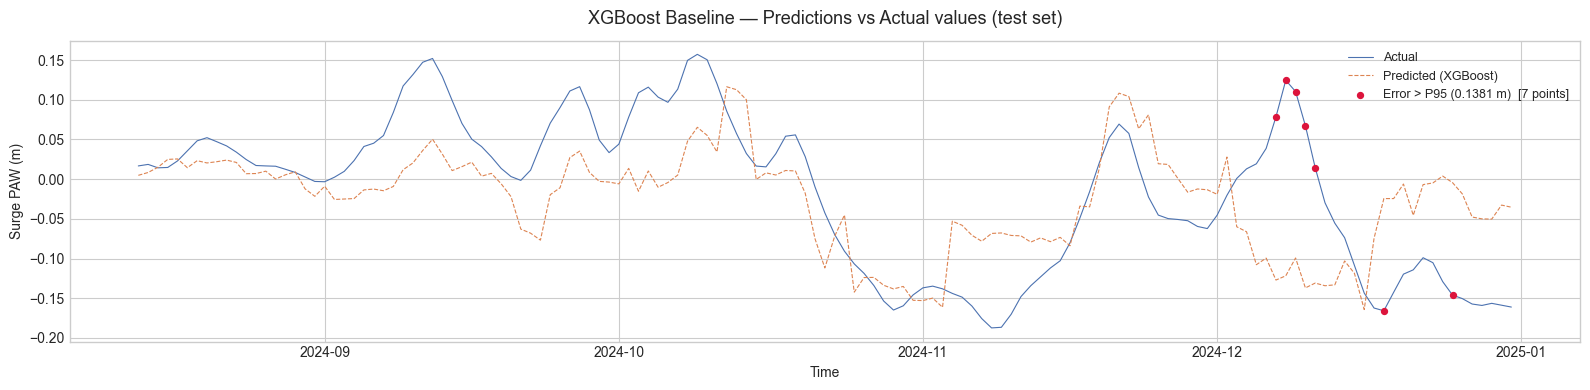

In [20]:
plot_predictions_vs_actual(
    y_paw_test, y_test_pred,
    title='XGBoost Baseline — Predictions vs Actual values (test set)',
    ylabel='Surge PAW (m)',
    save_path='plots/paw/paw_baseline_predictions.png',
)

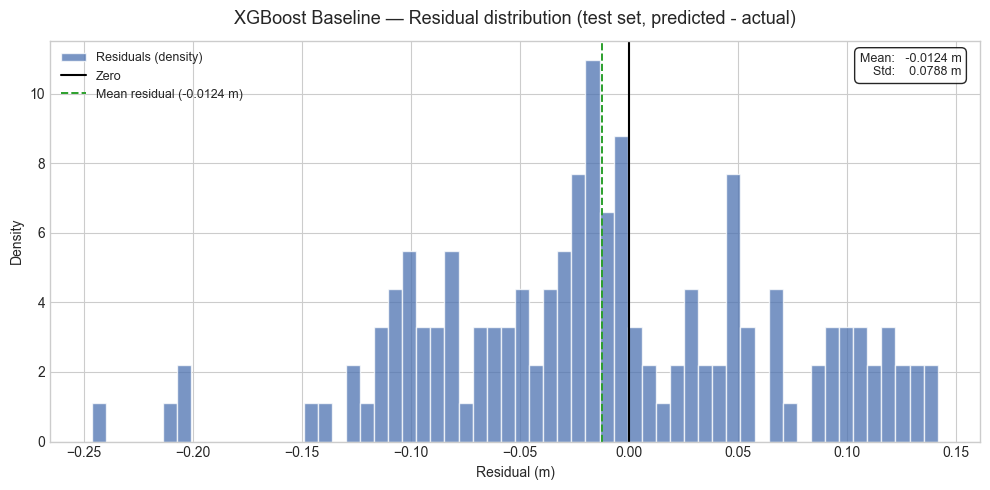

In [21]:
plot_residuals(
    y_paw_test, y_test_pred,
    title='XGBoost Baseline — Residual distribution (test set, predicted - actual)',
    save_path='plots/paw/paw_baseline_residuals.png',
)

In [22]:
abs_errors = np.abs(y_test_pred - y_paw_test)

# Top 10 worst absolute errors

df_errors = pd.DataFrame({
    'Actual (m)':     y_paw_test.values,
    'Predicted (m)':  y_test_pred,
    'Abs. error (m)': abs_errors,
}, index=y_paw_test.index)

top10 = df_errors.nlargest(10, 'Abs. error (m)')

print('=== Top 10 worst absolute errors — XGBoost Baseline (test set) ===')
print(f"  {'Date':<25} {'Actual (m)':>12} {'Predicted (m)':>14} {'Abs. error (m)':>16}")
print('  ' + '-' * 70)

for ts, row in top10.iterrows():
    print(f"  {str(ts):<25} {row['Actual (m)']:>12.4f} "
          f"{row['Predicted (m)']:>14.4f} {row['Abs. error (m)']:>16.4f}")

=== Top 10 worst absolute errors — XGBoost Baseline (test set) ===
  Date                        Actual (m)  Predicted (m)   Abs. error (m)
  ----------------------------------------------------------------------
  2024-12-08 00:00:00             0.1245        -0.1217           0.2462
  2024-12-09 00:00:00             0.1103        -0.0993           0.2095
  2024-12-07 00:00:00             0.0785        -0.1271           0.2056
  2024-12-10 00:00:00             0.0673        -0.1370           0.2042
  2024-12-11 00:00:00             0.0145        -0.1309           0.1453
  2024-12-25 00:00:00            -0.1460        -0.0044           0.1416
  2024-12-18 00:00:00            -0.1658        -0.0245           0.1413
  2024-12-06 00:00:00             0.0387        -0.0994           0.1381
  2024-12-24 00:00:00            -0.1291         0.0039           0.1329
  2024-12-26 00:00:00            -0.1504        -0.0186           0.1319


# 6. Hyperparameter Tuning

## 6.1 PCA comparison 90% vs 95%

In [23]:
# Reload variables if not available in memory
try:
    n_comp_per_threshold
except NameError:
    _pca_thresh = load_model('models/paw/paw_pca.pkl')
    _cum_var = np.cumsum(_pca_thresh.explained_variance_ratio_)
    n_comp_per_threshold = {}
    for _label, _thr in [('90%', 0.90), ('95%', 0.95), ('99%', 0.99)]:
        _idx = np.argmax(_cum_var >= _thr)
        n_comp_per_threshold[_label] = int(_idx) + 1 if _cum_var[_idx] >= _thr else len(_cum_var)
    print('n_comp_per_threshold recomputed from saved PCA.')

try:
    X_paw_train_pca
except NameError:
    _scaler = load_model('models/paw/paw_scaler.pkl')
    _pca = load_model('models/paw/paw_pca.pkl')
    try:
        _X_tr_sc = _scaler.transform(X_paw_train)
        _X_te_sc = _scaler.transform(X_paw_test)
    except NameError:
        raise NameError(
            "X_paw_train / X_paw_test are not in scope. "
            "Run cells 1\u201317 first to load and split the raw data."
        )
    X_paw_train_pca = _pca.transform(_X_tr_sc)
    X_paw_test_pca = _pca.transform(_X_te_sc)
    print('PCA-95 reloaded from disk.')
try:
    paw_baseline
except NameError:
    paw_baseline = load_model('models/paw/xgb_paw_baseline.pkl')

X_tune_train, X_tune_test, selected, xgb_95, xgb_90 = select_pca_variant(
    X_paw_train_pca, X_paw_test_pca,
    y_paw_train, y_paw_test,
    n_components_90=n_comp_per_threshold['90%'],
)

PCA-95 shape train/test: (560, 115) | (141, 115)
PCA-90 shape train/test: (560, 67) | (141, 67)
Training complete

=== PCA-95 vs PCA-90 comparison (test set, default XGBoost) ===
                       MAE    RMSE      R²
PCA-95 (115 comp.) 0.06388 0.07977 0.28679
PCA-90 (67 comp.)  0.06287 0.08012 0.28049

Variant selected for tuning: PCA-95 (115 components)
  → Test R²: 0.28679 (highest among the two variants)


## 6.2 Hyperparameter search and best parameters

In [24]:
SEARCH_RESULTS_PATH = 'models/paw/xgb_paw_search.json'

param_dist = {
    'n_estimators':     [50, 100, 200, 300, 400],
    'max_depth':        [2, 3, 4],
    'learning_rate':    [0.005, 0.01, 0.05, 0.1],
    'subsample':        [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [5, 10, 15, 20],
    'reg_lambda':       [1.0, 5.0, 10.0, 20.0],
    'reg_alpha':        [0.5, 1.0, 2.0, 5.0],
    'gamma':            [0, 0.1, 0.5, 1.0],
}

best_params, best_mae_cv = run_or_load_hyperparameter_search(
    X_tune_train, y_paw_train,
    param_dist=param_dist,
    results_path=SEARCH_RESULTS_PATH,
    n_iter=60,
    n_splits=5,
)


Search results loaded from models/paw/xgb_paw_search.json


In [25]:
print('=' * 55)
print('  BEST HYPERPARAMETERS — RandomizedSearchCV')
print('=' * 55)
for k, v in sorted(best_params.items()):
    print(f'  {k:<22}: {v}')
print(f'\n  Mean CV MAE (5 folds): {best_mae_cv:.5f} m')
print('=' * 55)


  BEST HYPERPARAMETERS — RandomizedSearchCV
  colsample_bytree      : 0.5
  gamma                 : 0
  learning_rate         : 0.05
  max_depth             : 4
  min_child_weight      : 20
  n_estimators          : 300
  reg_alpha             : 0.5
  reg_lambda            : 1.0
  subsample             : 0.7

  Mean CV MAE (5 folds): 0.06537 m


model_tuned loaded from models/paw/xgb_paw_tuned.pkl
  PAW XGBoost — Baseline vs Tuned
  Model | Set         MAE (m)  RMSE (m)      R²
  ----------------------------------------------------
  Baseline — Train    0.00028   0.00038  1.0000
  Baseline — Test     0.06388   0.07977  0.2868
  ----------------------------------------------------
  Tuned — Train       0.01344   0.01796  0.9711
  Tuned — Test        0.05534   0.06635  0.5066

  Delta test (Tuned - Baseline):
  MAE:  -0.00854 m  (improvement)
  RMSE: -0.01342 m  (improvement)
  R²:   +0.21985    (improvement)


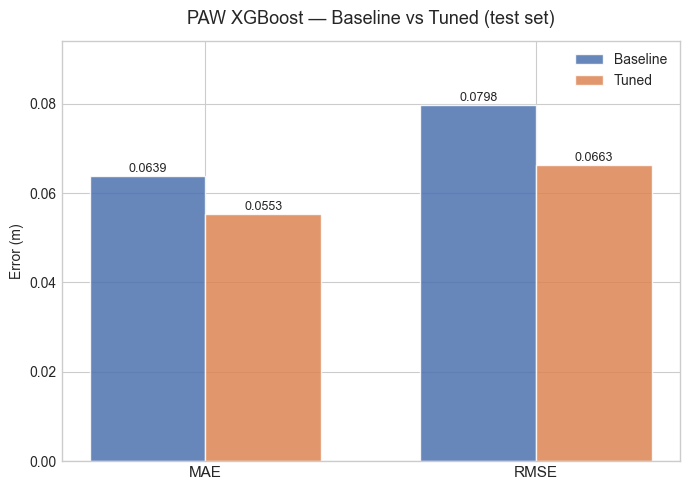

In [26]:
MODEL_PATH = 'models/paw/xgb_paw_tuned.pkl'

model_tuned = load_or_train_tuned(
    X_tune_train, y_paw_train,
    best_params=best_params,
    model_path=MODEL_PATH,
)

pred_baseline = xgb_95.predict(X_tune_test) if 'PCA-95' in selected else xgb_90.predict(X_tune_test)
pred_tuned = model_tuned.predict(X_tune_test)

rows = [
    compute_metrics(y_paw_train, xgb_95.predict(X_tune_train) if 'PCA-95' in selected else xgb_90.predict(X_tune_train), 'Baseline — Train'),
    compute_metrics(y_paw_test,  pred_baseline, 'Baseline — Test'),
    compute_metrics(y_paw_train, model_tuned.predict(X_tune_train), 'Tuned — Train'),
    compute_metrics(y_paw_test,  pred_tuned, 'Tuned — Test'),
]

print_comparative_table(rows, title='PAW XGBoost — Baseline vs Tuned')
print_delta(rows[1], rows[3])

plot_metrics_comparison(
    baseline_mae=rows[1]['MAE (m)'],
    baseline_rmse=rows[1]['RMSE (m)'],
    tuned_mae=rows[3]['MAE (m)'],
    tuned_rmse=rows[3]['RMSE (m)'],
    title='PAW XGBoost — Baseline vs Tuned (test set)',
    save_path='plots/paw/metrics_comparison.png',
)

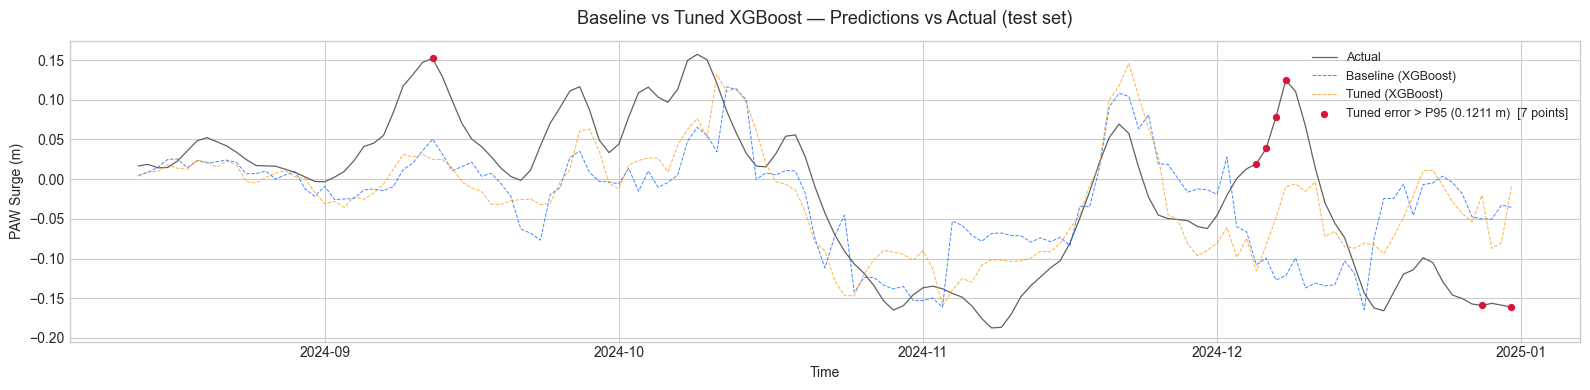

In [27]:
plot_baseline_vs_tuned_preds(
    y_paw_test, pred_baseline, pred_tuned,
    title='Baseline vs Tuned XGBoost — Predictions vs Actual (test set)',
    ylabel='PAW Surge (m)',
    save_path='plots/paw/paw_baseline_vs_tuned_pred.png',
)

## 6.3 Visual comparison of test set metrics

In [28]:
# Error table for tuned model on test set
df_err_tuned = pd.DataFrame({
    'Actual (m)':    y_paw_test.values,
    'Predicted (m)': pred_tuned,
    'Abs. error (m)': np.abs(y_paw_test.values - pred_tuned),
    'Sign correct':   np.sign(y_paw_test.values) == np.sign(pred_tuned),
}, index=y_paw_test.index)

# Top 10 worst absolute errors
top10_tuned = df_err_tuned.nlargest(10, 'Abs. error (m)')
print('\n=== Top 10 worst absolute errors — model_tuned (test set) ===')
print(top10_tuned.to_string(float_format='{:.5f}'.format))

# December 2024 extreme event analysis
print('\n=== December 2024 analysis ===')
mask_dec = df_err_tuned.index.month == 12
if mask_dec.sum() > 0:
    df_dec = df_err_tuned[mask_dec].copy()
    n_wrong_sign = (~df_dec['Sign correct']).sum()
    print(df_dec.sort_index().to_string(float_format='{:.5f}'.format))
    print(f'\nWrong sign cases in December: {n_wrong_sign} of {len(df_dec)}')
else:
    print('No December samples in test set.')




=== Top 10 worst absolute errors — model_tuned (test set) ===
            Actual (m)  Predicted (m)  Abs. error (m)  Sign correct
time                                                               
2024-12-31    -0.16108       -0.00919         0.15190          True
2024-12-28    -0.15905       -0.02034         0.13870          True
2024-12-05     0.01932       -0.11566         0.13498         False
2024-12-08     0.12451       -0.00955         0.13406         False
2024-12-07     0.07852       -0.04855         0.12707         False
2024-09-12     0.15196        0.02494         0.12702          True
2024-12-06     0.03870       -0.08311         0.12181         False
2024-12-24    -0.12905       -0.00797         0.12109          True
2024-12-25    -0.14597       -0.02862         0.11736          True
2024-12-23    -0.10522        0.01135         0.11657         False

=== December 2024 analysis ===
            Actual (m)  Predicted (m)  Abs. error (m)  Sign correct
time                 

# 7. SHAP Analysis

## 7.1 SHAP values computation

In [29]:
try:
    model_tuned
except NameError:
    model_tuned = joblib.load('models/paw/xgb_paw_tuned.pkl')
    print('model_tuned reloaded from disk.')

try:
    pca
except NameError:
    pca = joblib.load('models/paw/paw_pca.pkl')
    print('pca reloaded from disk.')

try:
    X_tune_test
except NameError:
    _scaler = joblib.load('models/paw/paw_scaler.pkl')
    try:
        _X_te_sc = _scaler.transform(X_paw_test)
    except NameError:
        raise NameError(
            "X_paw_test is not in scope. "
            "Run cells 1\u201317 first to load and split the raw data."
        )
    _X_te_pca = pca.transform(_X_te_sc)
    _n_feat = model_tuned.n_features_in_
    X_tune_test = _X_te_pca[:, :_n_feat]
    print('X_tune_test reconstructed from disk.')

# PCA component names: PC1, PC2, ...
n_components = X_tune_test.shape[1]
pc_names = [f'PC{i+1}' for i in range(n_components)]


explainer   = shap.TreeExplainer(model_tuned)
shap_values = explainer.shap_values(X_tune_test, check_additivity=False, approximate=True)


shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_tune_test,
    feature_names=pc_names,
)

print(f'shap_values shape:  {shap_values.shape}')
print(f'Base value (E[f]):  {explainer.expected_value:.6f} m')

shap_values shape:  (141, 115)
Base value (E[f]):  0.019940 m


## 7.2 Summary plot (beeswarm)

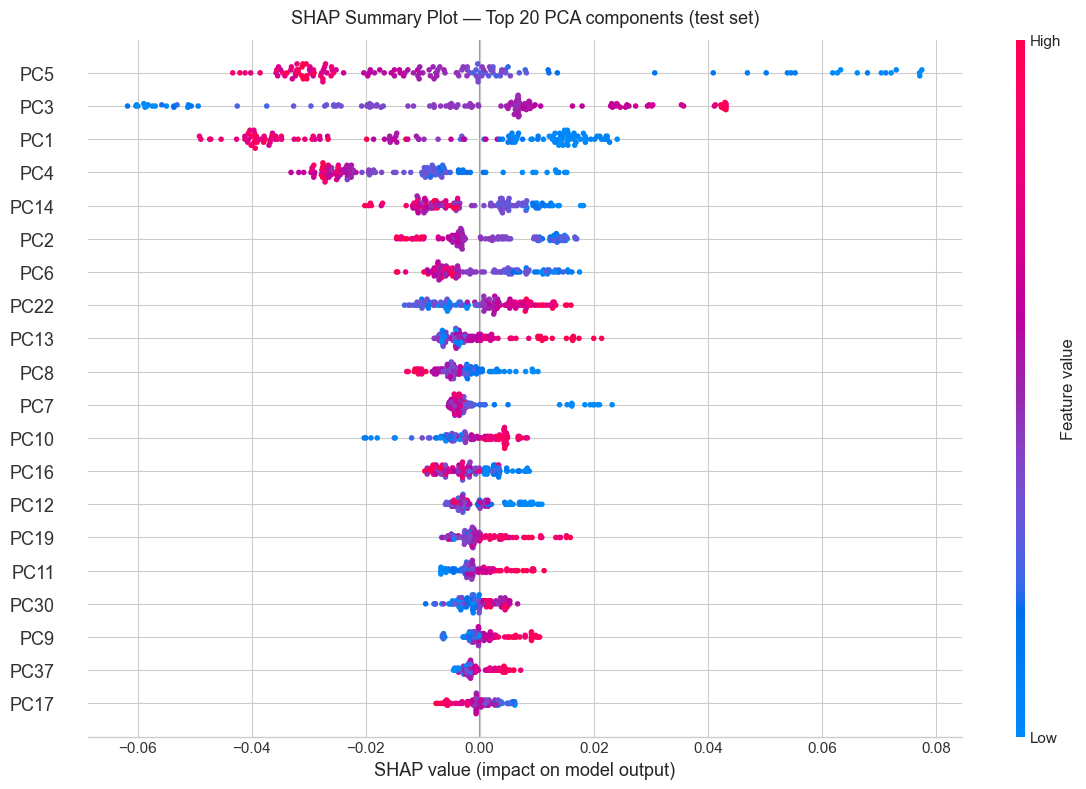


=== Top 20 PCA components by SHAP importance ===
Component  SHAP importance  Var. explained %
      PC5          0.02308           4.99949
      PC3          0.02211           7.23948
      PC1          0.02137           9.98631
      PC4          0.01768           5.64120
     PC14          0.00790           1.82984
      PC2          0.00773           7.46538
      PC6          0.00695           4.40929
     PC22          0.00630           1.01524
     PC13          0.00505           2.05718
      PC8          0.00492           3.21979
      PC7          0.00483           3.87866
     PC10          0.00459           2.67589
     PC16          0.00423           1.56857
     PC12          0.00374           2.26950
     PC19          0.00320           1.24120
     PC11          0.00308           2.39377
     PC30          0.00271           0.60939
      PC9          0.00252           2.91578
     PC37          0.00246           0.47776
     PC17          0.00234           1.46944


In [30]:
mean_abs_shap_pc = np.abs(shap_values).mean(axis=0)
top20_idx  = np.argsort(mean_abs_shap_pc)[::-1][:20]
top20_names = [pc_names[i] for i in top20_idx]

plot_shap_summary_beeswarm(
    shap_values[:, top20_idx],
    X_paw_test_pca[:, top20_idx],
    top20_names,
    title='SHAP Summary Plot — Top 20 PCA components (test set)',
    save_path='plots/paw/shap_summary_beeswarm.png',
    max_display=20,
)

df_top20 = pd.DataFrame({
    'Component':        [pc_names[i] for i in top20_idx],
    'SHAP importance':  mean_abs_shap_pc[top20_idx],
    'Var. explained %': pca.explained_variance_ratio_[top20_idx] * 100,
})
print('\n=== Top 20 PCA components by SHAP importance ===')
print(df_top20.to_string(index=False, float_format='{:.5f}'.format))

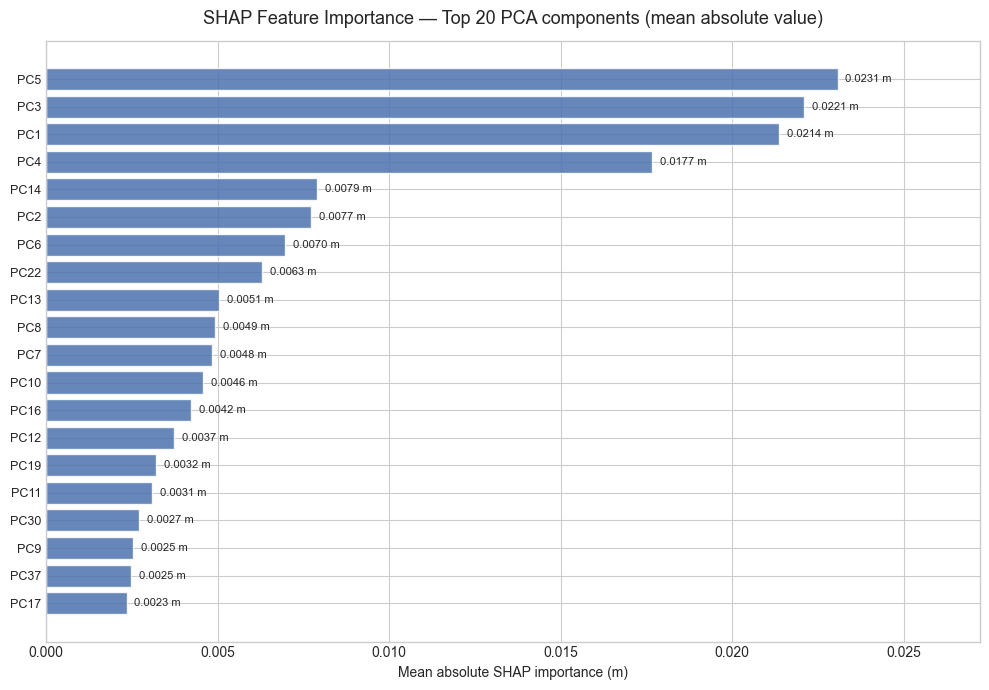

In [31]:
plot_shap_importance_bar(
    mean_abs_shap_pc, pc_names,
    title='SHAP Feature Importance — Top 20 PCA components (mean absolute value)',
    save_path='plots/paw/shap_importance_bar.png',
    top_n=20,
)

## 7.3 Waterfall plots

Date:           2024-10-09
Actual value:   0.15715 m
Predicted:      0.07635 m
Absolute error: 0.08080 m


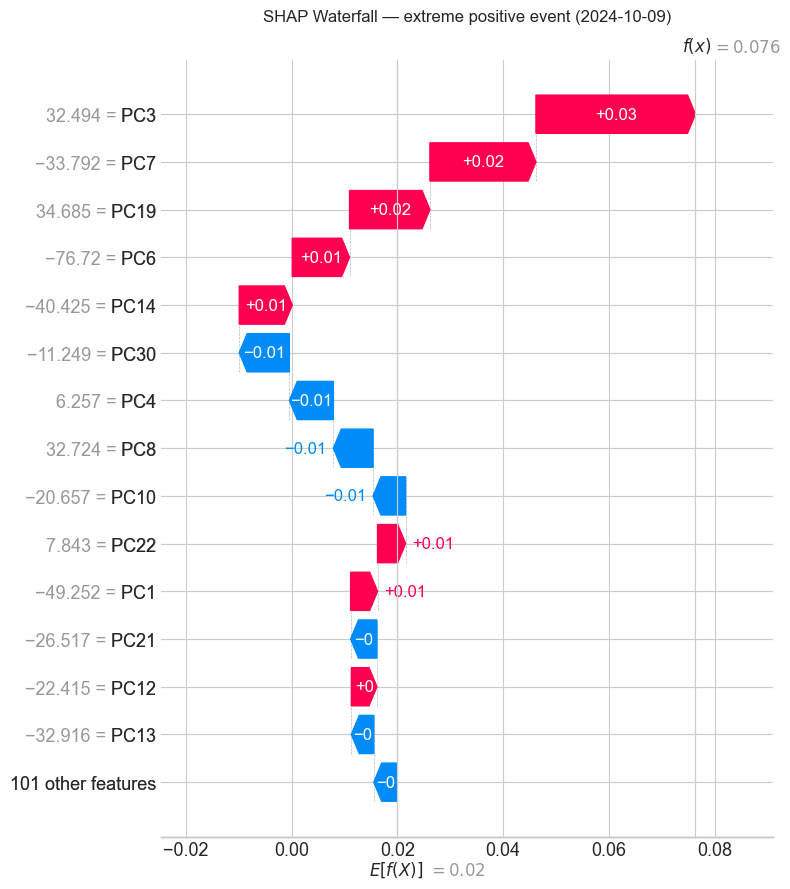

In [32]:

idx_pos = int(np.argmax(y_paw_test.values))
date_pos = y_paw_test.index[idx_pos]
actual_pos = y_paw_test.values[idx_pos]
predicted_pos = model_tuned.predict(X_paw_test_pca[[idx_pos]])[0]
error_pos = abs(actual_pos - predicted_pos)

print(f'Date:           {date_pos.date()}')
print(f'Actual value:   {actual_pos:.5f} m')
print(f'Predicted:      {predicted_pos:.5f} m')
print(f'Absolute error: {error_pos:.5f} m')

plot_shap_waterfall(
    shap_explanation, idx_pos,
    title=f'SHAP Waterfall — extreme positive event ({date_pos.date()})',
    save_path='plots/paw/shap_waterfall_extreme_pos.png',
    max_display=15,
)

Date:           2024-11-08
Actual value:   -0.18733 m
Predicted:      -0.10138 m
Absolute error: 0.08596 m


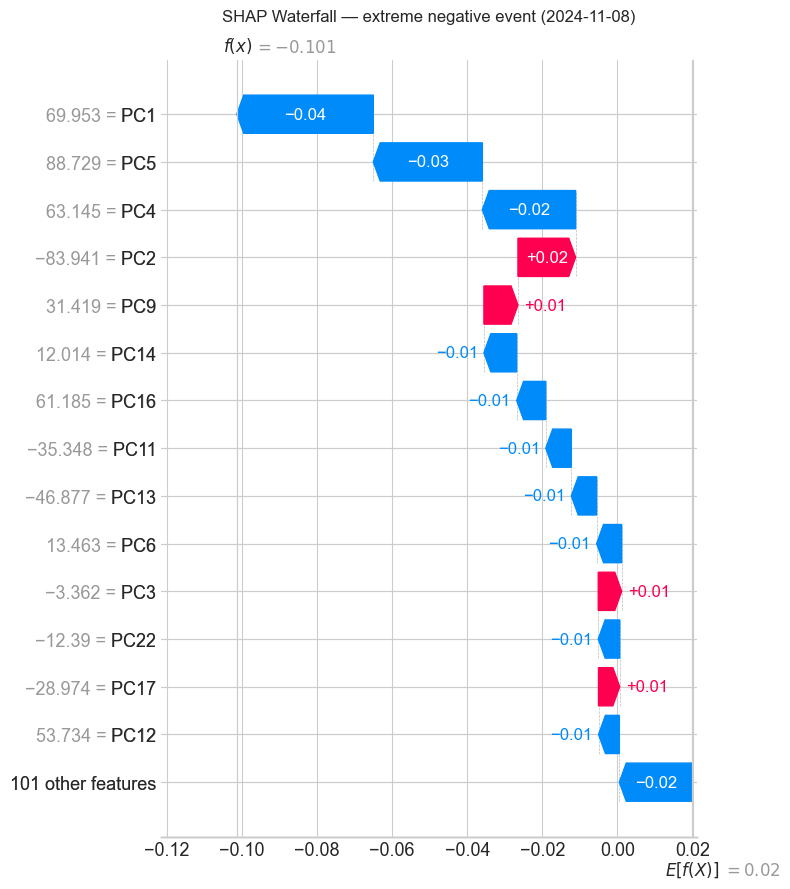

In [33]:

idx_neg = int(np.argmin(y_paw_test.values))
date_neg = y_paw_test.index[idx_neg]
actual_neg = y_paw_test.values[idx_neg]
predicted_neg = model_tuned.predict(X_paw_test_pca[[idx_neg]])[0]
error_neg = abs(actual_neg - predicted_neg)

print(f'Date:           {date_neg.date()}')
print(f'Actual value:   {actual_neg:.5f} m')
print(f'Predicted:      {predicted_neg:.5f} m')
print(f'Absolute error: {error_neg:.5f} m')

plot_shap_waterfall(
    shap_explanation, idx_neg,
    title=f'SHAP Waterfall — extreme negative event ({date_neg.date()})',
    save_path='plots/paw/shap_waterfall_extreme_neg.png',
    max_display=15,
)

Median y_paw_test: 0.01350 m
Date:              2024-09-19
Actual value:      0.01350 m
Predicted:         -0.03175 m
Absolute error:    0.04525 m


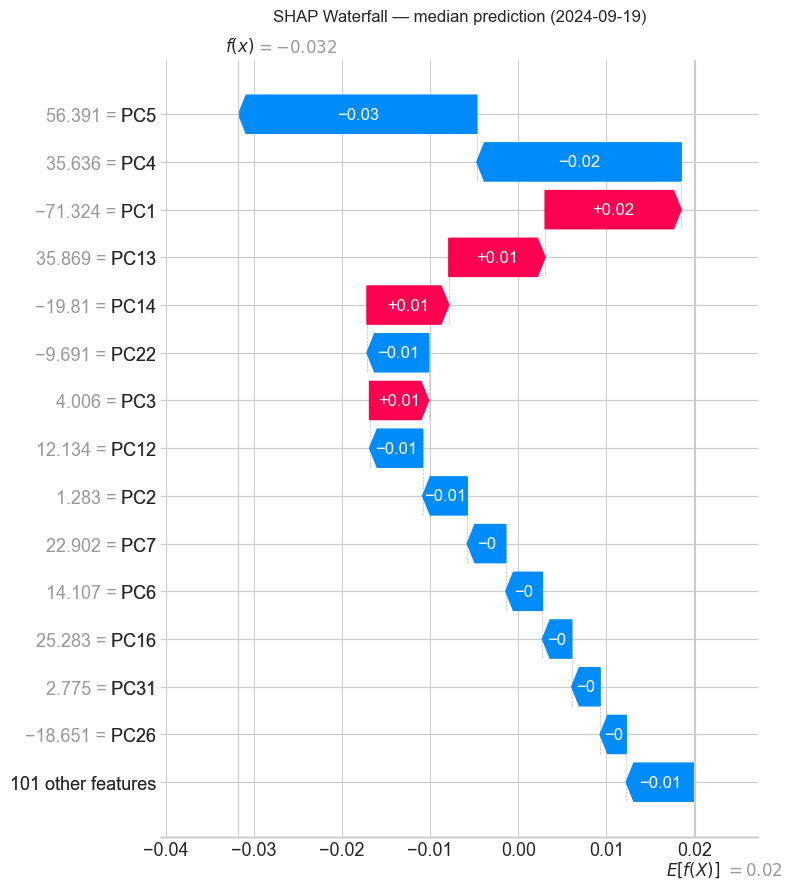

In [34]:

median = np.median(y_paw_test.values)
idx_med = int(np.argmin(np.abs(y_paw_test.values - median)))
date_med = y_paw_test.index[idx_med]
actual_med = y_paw_test.values[idx_med]
predicted_med = model_tuned.predict(X_paw_test_pca[[idx_med]])[0]
error_med = abs(actual_med - predicted_med)

print(f'Median y_paw_test: {median:.5f} m')
print(f'Date:              {date_med.date()}')
print(f'Actual value:      {actual_med:.5f} m')
print(f'Predicted:         {predicted_med:.5f} m')
print(f'Absolute error:    {error_med:.5f} m')

plot_shap_waterfall(
    shap_explanation, idx_med,
    title=f'SHAP Waterfall — median prediction ({date_med.date()})',
    save_path='plots/paw/shap_waterfall_median.png',
    max_display=15,
)

## 7.4 Spatial importance map

In [35]:
import re

# Back-projection: PCA space → original feature space
mean_abs_shap = np.abs(shap_values).mean(axis=0)
n_sel = mean_abs_shap.shape[0]
feature_importance_original = mean_abs_shap @ np.abs(pca.components_[:n_sel, :])

pat = re.compile(r'^(.+)_lat([\d.\-]+)_lon([\d.\-]+)$')
feature_names_orig = list(pp_wide.columns)
grid_imp_dict = {}
for col_i, fname in enumerate(feature_names_orig):
    m = pat.match(fname)
    if not m:
        continue
    lat, lon = float(m.group(2)), float(m.group(3))
    grid_imp_dict[(lat, lon)] = grid_imp_dict.get((lat, lon), 0.0) + feature_importance_original[col_i]

grid_points = sorted(grid_imp_dict.keys())
lats = np.array([p[0] for p in grid_points])
lons = np.array([p[1] for p in grid_points])
imp  = np.array([grid_imp_dict[p] for p in grid_points])

print(f'Grid points found: {len(grid_points)}')
print(f'Importance min|max: {imp.min():.4f} / {imp.max():.4f}')

plot_shap_geo_importance(
    lats, lons, imp,
    title='Back-projected SHAP importance — paw_pressures (European grid)',
    save_path='plots/paw/shap_geo_importance.png',
    venice_grid_lat=45.75, venice_grid_lon=12.25,
    lon_range=(-22, 32), lat_range=(28, 62),
    colorbar_title='SHAP importance<br>(back-projected)',
    projection='mercator',
)

Grid points found: 1420
Importance min|max: 0.0211 / 0.0265


In [36]:
_baseline_model   = xgb_95 if 'PCA-95' in selected else xgb_90
_pred_base_train  = _baseline_model.predict(X_tune_train)
_pred_tuned_train = model_tuned.predict(X_tune_train)

top_shap_lines = [
    f'{i+1}. {row["Component"]:<8}  →  {row["SHAP importance"]:.4f} m  '
    f'(var. explained: {row["Var. explained %"]:.1f}%)'
    for i, (_, row) in enumerate(df_top20.head(5).iterrows())
]

print_final_summary(
    title='XGBoost PAW Model',
    dataset_info=(
        f'  Target:       PAW surge at Venice (45.75N, 12.25E)\n'
        f'  Features:     {X_tune_train.shape[1]} PCA components ({selected})\n'
        f'  Train set:    {y_paw_train.index.min().strftime("%Y-%m-%d")} → '
        f'{y_paw_train.index.max().strftime("%Y-%m-%d")}  ({len(y_paw_train):,} samples)\n'
        f'  Test set:     {y_paw_test.index.min().strftime("%Y-%m-%d")} → '
        f'{y_paw_test.index.max().strftime("%Y-%m-%d")}  ({len(y_paw_test):,} samples)'
    ),
    metrics=[
        compute_metrics(y_paw_train, _pred_base_train,  'Baseline — Train'),
        compute_metrics(y_paw_test,  pred_baseline,     'Baseline — Test'),
        compute_metrics(y_paw_train, _pred_tuned_train, 'Tuned    — Train'),
        compute_metrics(y_paw_test,  pred_tuned,        'Tuned    — Test'),
    ],
    top_shap_lines=top_shap_lines,
)


  FINAL SUMMARY — XGBoost PAW Model

  Dataset
  ------------------------------------------------------------
  Target:       PAW surge at Venice (45.75N, 12.25E)
  Features:     115 PCA components (PCA-95 (115 components))
  Train set:    2019-01-31 → 2024-08-12  (560 samples)
  Test set:     2024-08-13 → 2024-12-31  (141 samples)

  Model performance
  ------------------------------------------------------------
  Model                     MAE (m)   RMSE (m)       R²
  ------------------------------------------------------------
  Baseline — Train          0.00028    0.00038   1.0000
  Baseline — Test           0.06388    0.07977   0.2868
  ------------------------------------------------------------
  Tuned    — Train          0.01344    0.01796   0.9711
  Tuned    — Test           0.05534    0.06635   0.5066
  ------------------------------------------------------------

  Top SHAP features
  ------------------------------------------------------------
  1. PC5       →  0.0231 m  (